In [1]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("../data/processed/df_final_eda.csv")

df.head()

,ID Estacion,Autoridad Ambiental,Estación,Latitud,Longitud,Variable,Unidades,Tiempo de exposición (horas),Año,Promedio,...,Fechas/horas del máximo,Mínimo,Fechas/horas del mínimo,Días de excedencias,Código del Departamento,Nombre del Departamento,Código del Municipio,Nombre del Municipio,Tipo de Estación,Ubicacion
0,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,DViento,deg,1,"2,011",256.8,...,29/11/2011 1:00,1.3,29/11/2011 7:00,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517)
1,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,DViento,deg,24,"2,011",257.4,...,16/11/2011 0:00,99.7,8/11/2011 0:00,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517)
2,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,PLiquida,mm,1,"2,011",4,...,20/12/2011 2:00,1.5,07/11/2011 23:00:00 - 08/11/2011 05:00:00 - 13...,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517)
3,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,P,mmHg,1,"2,011",645.9,...,12/09/2011 10:00,641.6,27/10/2011 17:00,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517)
4,"9,020",AMVA,I.E. COL. COLOMBIA,6.378517,-75.443986,P,mmHg,24,"2,011",645.9,...,20/10/2011 0:00,644,27/10/2011 0:00,0,5,Antioquia,5308.0,Girardota,Fija,POINT (-75.443986 6.378517)


In [3]:
df.columns

Index(['ID Estacion', 'Autoridad Ambiental', 'Estación', 'Latitud', 'Longitud',
       'Variable', 'Unidades', 'Tiempo de exposición (horas)', 'Año',
       'Promedio', 'Suma', 'No. de datos', 'Representatividad Temporal',
       'Excedencias limite actual', 'Porcentaje excedencias limite actual',
       'Mediana', 'Percentil 98', 'Máximo', 'Fechas/horas del máximo',
       'Mínimo', 'Fechas/horas del mínimo', 'Días de excedencias',
       'Código del Departamento', 'Nombre del Departamento',
       'Código del Municipio', 'Nombre del Municipio', 'Tipo de Estación',
       'Ubicacion'],
      dtype='str')

# APLICAMOS UN FORMATO A LA COLUMNA DEL DF DE FECHA/HORA DEL MINIMO DEBIDO A UN ERROR EN EL FORMATO ACTUAL

Se formatea la columna del df con la finalidad de contar con campos más legibles y limpios a la hora de hacer un procesamiento de los datos

In [4]:
df["Fechas/horas del mínimo"] = df["Fechas/horas del mínimo"].astype(str)

df["Fechas/horas del mínimo"] = df["Fechas/horas del mínimo"].str.split(" - ").str[0]

df["Fechas/horas del mínimo"] = df["Fechas/horas del mínimo"].str.replace(r"[^\d:/\s]", "", regex=True)

df["Fechas/horas del mínimo"] = df["Fechas/horas del mínimo"].str.strip()

df["Fechas/horas del mínimo"] = pd.to_datetime(
    df["Fechas/horas del mínimo"],
    errors="coerce",
    dayfirst=True
)

In [5]:
df["Fechas/horas del mínimo"] = pd.to_datetime(
    df["Fechas/horas del mínimo"],
    errors="coerce",
    dayfirst=True
)

In [6]:
df["Fechas/horas del mínimo"].head()
df["Fechas/horas del mínimo"].isnull().sum()

np.int64(16413)

In [7]:
df["min_mes"] = df["Fechas/horas del mínimo"].dt.month
df["min_año"] = df["Fechas/horas del mínimo"].dt.year

## PREPARACION DEL DATA SET (ELIMAR COLUMNAS POCO RELEVANTES)

Eliminamos las columnas que no aportan un valor significativo al analisis del proceso con el fin del  tener unos datos timpos y consistentes. 
- ID Estacion, Código del Departamento, Código del municipio: Estas variables no aportan información predictiva y solo nos permiten identificar registros. 
- Latitud, Longitud: Estas variables presentan baja correlación, se decide eliminar estas variables ya que no explican el fenomeno. 
- Suma, No. de datos, Mediana, Percentil 98: Estas variables son derivadas por lo que serian redundantes en nuestro dataset, al dejar estas variables nos generaria colinealidad. 


In [8]:
columnas_eliminar = [
    "Código del Departamento",
    "Código del Municipio",
    "Latitud",
    "Longitud",
    "ID Estacion",
    "Suma",
    "No. de datos",
    "Mediana",
    "Percentil 98"
]

df_modelo = df.drop(columns=columnas_eliminar, errors="ignore")

# CODIFICACIÓN DE VARIABLES CATEGORICAS

Se transforman las variables categóricas en variables numéricas mediante One-Hot Encoding.

Se aplicó la técnica de One-Hot Encoding para transformar las variables categóricas en variables numéricas binarias.

Se utilizó el parámetro `drop_first=True` para evitar multicolinealidad, eliminando una de las categorías y utilizando las restantes como referencia.

In [9]:
df_modelo = pd.get_dummies(df_modelo, drop_first=True)

# ESCALADO DE VARIABLES

Se aplica estandarización a las variables numéricas para garantizar que todas tengan la misma escala.

Se seleccionaron únicamente las variables numéricas del dataset para aplicar el proceso de estandarización.

Posteriormente, se utilizó el método StandardScaler para transformar las variables, garantizando que todas tengan media cero y desviación estándar uno.

Este proceso es fundamental para evitar que variables con diferentes escalas afecten el rendimiento de los modelos, especialmente en técnicas como PCA.

In [10]:

df_numerico = df_modelo.select_dtypes(include=[np.number])

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numerico)

df_scaled = pd.DataFrame(df_scaled, columns=df_numerico.columns)

#  APLICAMOS PCA PARA REDUCCIÓN DE DIMENSIONALIDAD 

Se aplica Análisis de Componentes Principales (PCA) para reducir la dimensionalidad del dataset y facilitar la visualización de patrones.

In [13]:
df_numerico = df_modelo.select_dtypes(include=[np.number])

df_numerico = df_numerico.dropna()

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numerico)

df_scaled = pd.DataFrame(df_scaled, columns=df_numerico.columns)


Varianza explicada por cada componente:
[0.34878595 0.16817653]


# CONCLUSIONES DE LA VISUALIZACIÓN 

Al evidenciar una concentración amplia cerca del centro nos indica que el dataset maneja una buena homogeneidad en la mayoria de sus datos. Aunque contamos con presencias de algunos puntos alejados a la izquierda (PC1 y a la derecha PC2) los cuales podremos catalogar como los puntos extremos de contaminacion siendo estos puntos claves del analisis actual y que no podremos retirar debido a la completitu del dataset. 
A pesar de contar con alguna disperción de los datos vemos que la nube de disperción es algo moderada lo que indica que tenemos variabilidad en los datos. 
Al evidenciar la nube ligeramente inclinada podemos concluir que tenemos relación evidente entre variables  y nuestro PCA está capturando la estructura real del dataset.

In [16]:

pca = PCA(n_components=2)

pca_result = pca.fit_transform(df_scaled)

print("Varianza explicada por cada componente")
print(pca.explained_variance_ratio_)

df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])

Varianza explicada por cada componente
[0.34878595 0.16817653]


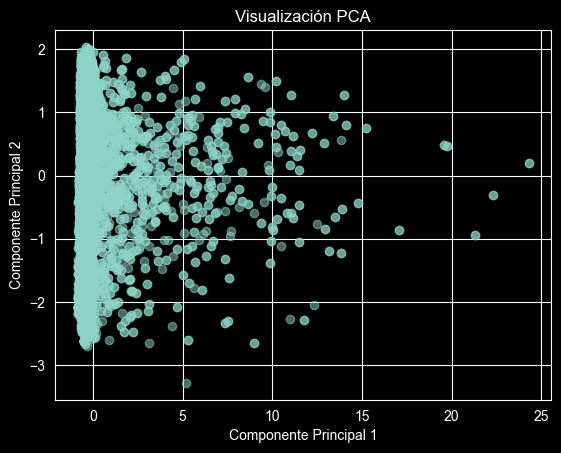

In [17]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.5)
plt.title("Visualización PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

# INSIGHTS PRINCIPALES

A partir del análisis exploratorio realizado, identificamos los siguientes
patrones y hallazgos relevantes:
1. **Valores extremos relevantes:** Estos fueron considerados outliers, pero
  debido a la naturaleza del dataset no son considerados errores, sino datos
  que representan eventos críticos de contaminación, por lo que no se
  eliminaron sino que se graficaron y analizaron para comprender su comportamiento.

2. **Estructura homogénea de los datos:** En nuestro PCA evidenciamos una alta
  concentración de datos en la región central de la gráfica, lo que nos ayudó
  a identificar que nuestro dataset presenta una buena homogeneidad y validez
  en los datos.

3. **Dispersión de datos poco relevante:** Aunque evidenciamos una leve
  dispersión de datos hacia la derecha, esta no resulta crítica para el análisis.

4. **Capacidad explicativa del PCA:** Nuestro PCA logró explicar aproximadamente
  un 51% de la varianza del dataset, lo que permite concluir que el dataset es
  relativamente complejo y no pudo ser reducido completamente a pocas dimensiones
  sin perder información valiosa.

5. **Relación fuerte entre variables de contaminación:** Se encontró una alta
  correlación entre las siguientes variables:
  * Excedencias límite actual
  * Porcentaje de excedencias
  * Días de excedencias

## PROBLEMAS DETECTADOS
- Presencia de valores faltantes en variables temporales debido a formatos inconsistentes.
- Registros con formatos incorrectos en fechas (rangos, caracteres inválidos).
- Variables categóricas con inconsistencias en nombres (ej: duplicados como "Bogotá" y "Bogotá D.C.").
- Presencia de outliers extremos en variables clave.

## POSIBLES LÍNEAS DE ANÁLISIS PARA FASES POSTERIORES

1. **Modelado predictivo:** Entrenar un modelo de machine learning para
   predecir los niveles de contaminación (Promedio, Percentil 98) según
   la ubicación geográfica, el tipo de estación y el año.

2. **Análisis geoespacial:** Cruzar los datos de latitud y longitud con
   mapas de Colombia para visualizar espacialmente las zonas más críticas
   de contaminación por departamento y municipio.

3. **Análisis temporal:** Estudiar la evolución de los niveles de
   contaminación a lo largo de los años para identificar tendencias de
   mejora o deterioro en la calidad del aire.

4. **Clasificación de estaciones:** Agrupar las estaciones de monitoreo
   mediante clustering (K-Means) según sus niveles de contaminantes para
   identificar perfiles de zonas críticas, moderadas y limpias.

5. **Análisis de excedencias:** Profundizar en las variables de excedencias
   para determinar qué departamentos superan con mayor frecuencia los
   límites permitidos de contaminación y correlacionarlo con variables
   socioeconómicas o industriales.
